In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz, welch

def generate_psd(f, cutoff, n, turb_power, noise_power):
    """
    Generates the Turbulence and Noise PSDs normalized to the requested total powers.
    """
    f_safe = np.maximum(f, f[0])
    if n == 1:
        psd_turb = np.where(f_safe <= cutoff, 
                            (f_safe / cutoff)**(-2/3), 
                            (f_safe / cutoff)**(-17/3))
    else:
        psd_turb = np.where(f_safe <= cutoff, 
                            1.0, 
                            (f_safe / cutoff)**(-17/3))
        
    df = np.gradient(f)

    f_s = f[-1] * 2 # Assuming f[-1] is Nyquist
    sinc_filter = np.sinc(f_safe / f_s)**2 
    psd_turb *= sinc_filter
    
    turb_integral = np.sum(psd_turb * df)
    psd_turb *= (turb_power / turb_integral)
    
    psd_noise = np.ones_like(f)
    noise_integral = np.sum(psd_noise * df)
    psd_noise *= (noise_power / noise_integral)
    
    return psd_turb, psd_noise

def generate_time_series_with_delay(psd_turb, psd_noise, f, delay_steps):
    """
    Generate time-domain open-loop measurements from PSDs and apply a continuous fractional delay.
    """
    N = len(f) * 2 - 1
    
    # Generate random phases for the positive frequencies
    phases_turb = np.exp(1j * np.random.uniform(0, 2*np.pi, len(f)))
    phases_noise = np.exp(1j * np.random.uniform(0, 2*np.pi, len(f)))
    
    # Create the single-sided complex spectrum
    Z_turb = np.sqrt(psd_turb) * phases_turb
    Z_noise = np.sqrt(psd_noise) * phases_noise
    
    # Combined open-loop spectrum
    Z_meas = Z_turb + Z_noise
    
    # Apply the fractional delay as a phase shift in the frequency domain
    # e_meas_prime compensates for the delay block mathematically (z^delay)
    # So we advance the signal by 'delay_steps' 
    phase_shift = np.exp(1j * 2 * np.pi * f * delay_steps / (2 * f[-1]))
    Z_meas_prime = Z_meas * phase_shift
    
    # Symmetrize to get a real-valued time-domain signal
    Z_full = np.concatenate([Z_meas_prime, np.conj(Z_meas_prime[-2:0:-1])])
    
    e_meas_prime = np.real(np.fft.ifft(Z_full))
    return e_meas_prime

def enforce_stability(b_coeffs, margin=0.99):
    """
    Finds the roots of the denominator polynomial. If any roots are outside 
    the unit circle (unstable), reflects them back inside.
    """
    roots = np.roots(b_coeffs)
    for i, r in enumerate(roots):
        if np.abs(r) >= 1.0:
            # Reflect the unstable pole inside the unit circle
            roots[i] = (1.0 / np.conj(r)) * margin
            
    # Reconstruct the polynomial coefficients from the stabilized roots
    stabilized_coeffs = np.poly(roots).real
    return stabilized_coeffs

def modified_rls_optimizer(e_meas_prime, p, q, lambda_factor=1.0, regularization=1e-3):
    N = len(e_meas_prime)
    theta_len = (p - 1) + q
    theta = np.zeros(theta_len)
    
    # Initialize P slightly smaller to prevent aggressive early transients
    P = np.eye(theta_len) * 1e3 
    y_alg = np.zeros(N)
    start_idx = max(p, q + 2)
    
    for i in range(start_idx, N):
        phi_b = y_alg[i-1 : i-p : -1] if p > 1 else np.array([])
        idx_a = np.arange(i-2, i-2-q, -1)
        phi_a = y_alg[idx_a] - e_meas_prime[idx_a]
        phi = np.concatenate([phi_b, phi_a])
        
        epsilon_alg = e_meas_prime[i] + theta @ phi
        
        P_phi = P @ phi
        K = P_phi / (lambda_factor + phi.T @ P_phi)
        
        # Standard covariance update
        P = (P - np.outer(K, P_phi)) / lambda_factor
        
        # LEAKAGE: Inject a tiny amount of noise into the diagonal to keep P well-conditioned
        # This prevents the parameters from exploding when fitting the noise floor
        P[np.diag_indices_from(P)] += regularization
        
        theta = theta - K * epsilon_alg
        y_alg[i] = - (theta @ phi)

    # Extract parameters
    b_coeffs_raw = np.concatenate([[1.0], theta[:p-1]])
    a_coeffs = theta[p-1:]
    
    # Force stability on the denominator
    b_coeffs = enforce_stability(b_coeffs_raw)
    
    return a_coeffs, b_coeffs

# def modified_rls_optimizer(e_meas_prime, p, q, ff=0.9995):
#     """
#     Time-domain optimization of Predictor parameters using the Modified RLS.
#     p: denominator filter order
#     q: numerator filter order
#     """
#     N = len(e_meas_prime)
    
#     # theta vector = [b_1 ... b_{p-1}, a_0 ... a_{q-1}]^T
#     theta_len = (p - 1) + q
#     theta = np.zeros(theta_len)
    
#     # Initialize covariance matrix P
#     P = np.eye(theta_len) * 1e4
    
#     y_alg = np.zeros(N)
    
#     # Start recursion taking into account maximum history lengths
#     start_idx = max(p, q + 2)
    
#     lambda_factor = ff
#     for i in range(start_idx, N):
#         # Construct the state vector phi(i) (Equation 22 in paper)
#         phi_b = y_alg[i-1 : i-p : -1] if p > 1 else np.array([])
#         idx_a = np.arange(i-2, i-2-q, -1)
#         phi_a = y_alg[idx_a] - e_meas_prime[idx_a]
#         phi = np.concatenate([phi_b, phi_a])
        
#         # Current error estimation
#         epsilon_alg = e_meas_prime[i] + theta @ phi

#         # RLS Gain and Covariance update WITH forgetting factor
#         P_phi = P @ phi
#         # Add lambda_factor to the denominator
#         K = P_phi / (lambda_factor + phi.T @ P_phi) 
#         # Divide by lambda_factor
#         P = (P - np.outer(K, P_phi)) / lambda_factor 
        
#         # Update parameters
#         theta = theta - K * epsilon_alg
        
#         # Compute current loop output constraint
#         y_alg[i] = - (theta @ phi)

#     # Extract stable parameters
#     b_coeffs = np.concatenate([[1.0], theta[:p-1]])
#     a_coeffs = theta[p-1:]
    
#     return a_coeffs, b_coeffs

def evaluate_and_plot(f, psd_turb, psd_noise, a_coeffs, b_coeffs, delay_steps, e_meas_prime, f_sampling):
    """
    Evaluate the analytical Rejection Transfer Function (RTF) and plot vs frequency SNR.
    """
    # Normalized frequencies (0 to pi)
    w = np.pi * f / f[-1]
    
    # Digital Frequency response of the controller C(z)
    _, C_w = freqz(a_coeffs, b_coeffs, worN=w)
    
    # Compute the transfer function of the fractional delay plant H(z)
    # Loop plant includes: z^{-l}[m(1-z^{-1}) + z^{-1}]
    l = int(np.floor(delay_steps))
    m = delay_steps - l
    
    z = np.exp(1j * w)
    delay_plant = (z**(-l)) * (m * (1 - z**(-1)) + z**(-1))
    
    # Open loop response
    H_open = delay_plant * C_w
    
    # Rejection Transfer Function (RTF) = 1 / (1 + H_open)
    RTF = 1.0 / (1.0 + H_open)
    RTF_inv_squared = 1.0 / (np.abs(RTF)**2)
    
    # Ideal spectral SNR
    SNR_w = (psd_turb + psd_noise) / psd_noise
    fvec,meas_psd = welch(e_meas_prime,f_sampling,nperseg=512)
    
    # --- Visualization ---
    plt.figure(figsize=(10, 6))
    plt.loglog(f, SNR_w, 'k--', label='Target Spectral SNR (Ideal RTF$^{-2}$)')
    plt.loglog(fvec[1:], meas_psd[1:]/meas_psd[-10], '--.', lw=2, label='Generated noise PSD')
    plt.loglog(f, RTF_inv_squared, 'r-', lw=2, label='Achieved $|RTF|^{-2}$ (Modified RLS Predictor)')
    
    plt.axhline(1.0, color='grey', linestyle=':', label='Noise Floor (0 dB)')
    plt.title(f'Optimized Predictor RTF matching for Non-Integer Delay = {delay_steps} steps')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True, which='both', ls='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_multiple_orders(f, psd_turb, psd_noise, e_meas_prime, delay_steps, f_sampling, max_order=5):
    """
    Evaluates and plots the RTF for filter orders from 1 to max_order.
    (Assumes equal number of poles and zeros: p = q + 1)
    """
    plt.figure(figsize=(12, 8))
    fvec,meas_psd = welch(e_meas_prime,f_sampling,nperseg=512)
    
    # Ideal spectral SNR
    SNR_w = (psd_turb + psd_noise) / psd_noise
    plt.loglog(f, SNR_w, 'k--', lw=2, label='Target Spectral SNR (Ideal RTF$^{-2}$)')
    plt.loglog(fvec[1:], meas_psd[1:]/meas_psd[-10], '--.', lw=2, label='Generated noise PSD')

    colors = plt.cm.viridis(np.linspace(0, 0.9, max_order))
    
    w = np.pi * f / f[-1]
    l = int(np.floor(delay_steps))
    m = delay_steps - l
    z = np.exp(1j * w)
    delay_plant = (z**(-l)) * (m * (1 - z**(-1)) + z**(-1))

    for order in range(1, max_order + 1):
        # We set p_order = order + 1 (denominator length including a0=1)
        # and q_order = order (numerator length)
        p_order = order + 1 
        q_order = order
        
        # Optimize
        a_coeffs, b_coeffs = modified_rls_optimizer(e_meas_prime, p_order, q_order)
        
        # Evaluate C(z)
        _, C_w = freqz(a_coeffs, b_coeffs, worN=w)
        
        # Open loop & RTF
        H_open = delay_plant * C_w
        RTF = 1.0 / (1.0 + H_open)
        RTF_inv_squared = 1.0 / (np.abs(RTF)**2)
        
        plt.loglog(f, RTF_inv_squared, color=colors[order-1], 
                   label=f'Order {order} (p={p_order}, q={q_order})')

    plt.axhline(1.0, color='grey', linestyle=':', label='Noise Floor (0 dB)')
    plt.title(f'RTF Matching Across Different Predictor Orders (Delay = {delay_steps})')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Amplitude $|RTF|^{-2}$')
    plt.legend()
    plt.grid(True, which='both', ls='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def calculate_rtf(a_coeffs, b_coeffs, delay_steps, f_norm):
    """
    Computes the Rejection Transfer Function (RTF) magnitude squared.
    f_norm: normalized frequencies (0 to 0.5)
    """
    # z = exp(j * 2 * pi * f * Ts)
    w = 2 * np.pi * f_norm
    z = np.exp(1j * w)
    
    # Calculate Predictor Transfer Function P(z) = A(z) / B(z)
    # Note: scipy.signal.freqz can also be used here
    A_z = np.sum([a * z**(-k) for k, a in enumerate(a_coeffs)], axis=0)
    B_z = np.sum([b * z**(-k) for k, b in enumerate(b_coeffs)], axis=0)
    
    P_z = A_z / B_z
    
    # Open loop transfer function H_ol(z) includes the predictor, 
    # the integrator 1/(1 - z^-1), and the delay z^-d
    # H_ol(z) = P(z) * z^-d / (1 - z^-1)
    H_ol = P_z * (z**(-delay_steps)) #/ (1 - z**(-1))
    
    # Rejection Transfer Function: 1 / (1 + H_ol)
    RTF = 1 / (1 + H_ol)
    
    return np.abs(RTF)

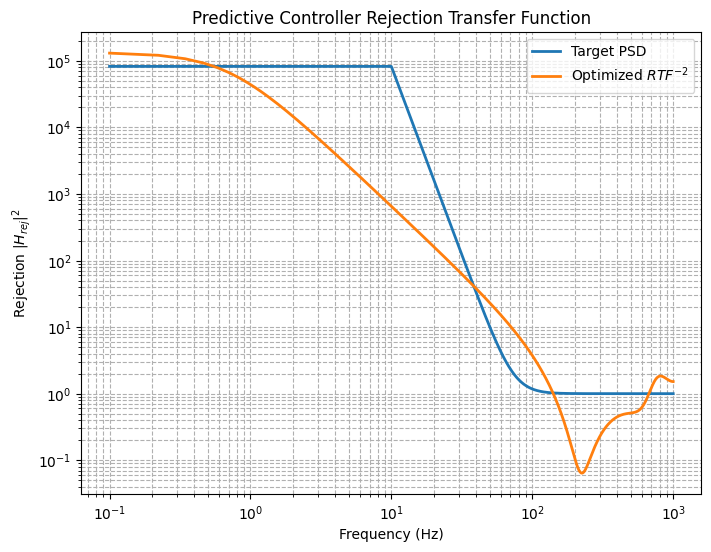

In [13]:
fs = 2000.0  # Hz
f = np.linspace(0.1, fs/2, 2048*4)
cutoff = 10.0 # Hz
delay_steps = 2.0
f_order = 4
n_rad = 2
SNR = 1000

# 2. Generate Data
psd_turb, psd_noise = generate_psd(f, cutoff, n=n_rad, turb_power=SNR, noise_power=1)
e_meas = generate_time_series_with_delay(psd_turb, psd_noise, f, delay_steps)

# 3. Optimize (using p=4, q=4 as an example)
a_coeffs, b_coeffs = modified_rls_optimizer(e_meas, p=f_order+1, q=f_order)

# 4. Evaluate and Plot
f_norm = f / fs
rtf = calculate_rtf(a_coeffs, b_coeffs, delay_steps, f_norm=f_norm)

plt.figure(figsize=(8, 6))
plt.loglog(f, (psd_turb+psd_noise)/psd_noise, label='Target PSD', linewidth=2)
plt.loglog(f, rtf**-2, label='Optimized $RTF^{-2}$', linewidth=2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Rejection $|H_{rej}|^2$')
plt.title('Predictive Controller Rejection Transfer Function')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

Optimal Numerator Coefficients (a): [0.40602888 0.25003914 0.20746072]
Optimal Denominator Coefficients (b): [ 1.         -0.39880721 -0.33199302 -0.25899586]


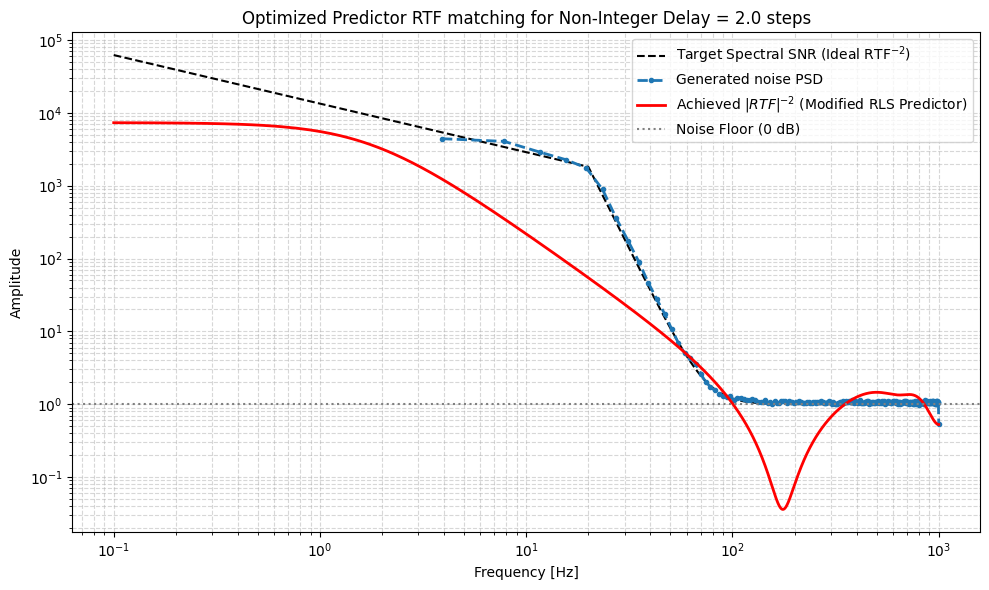

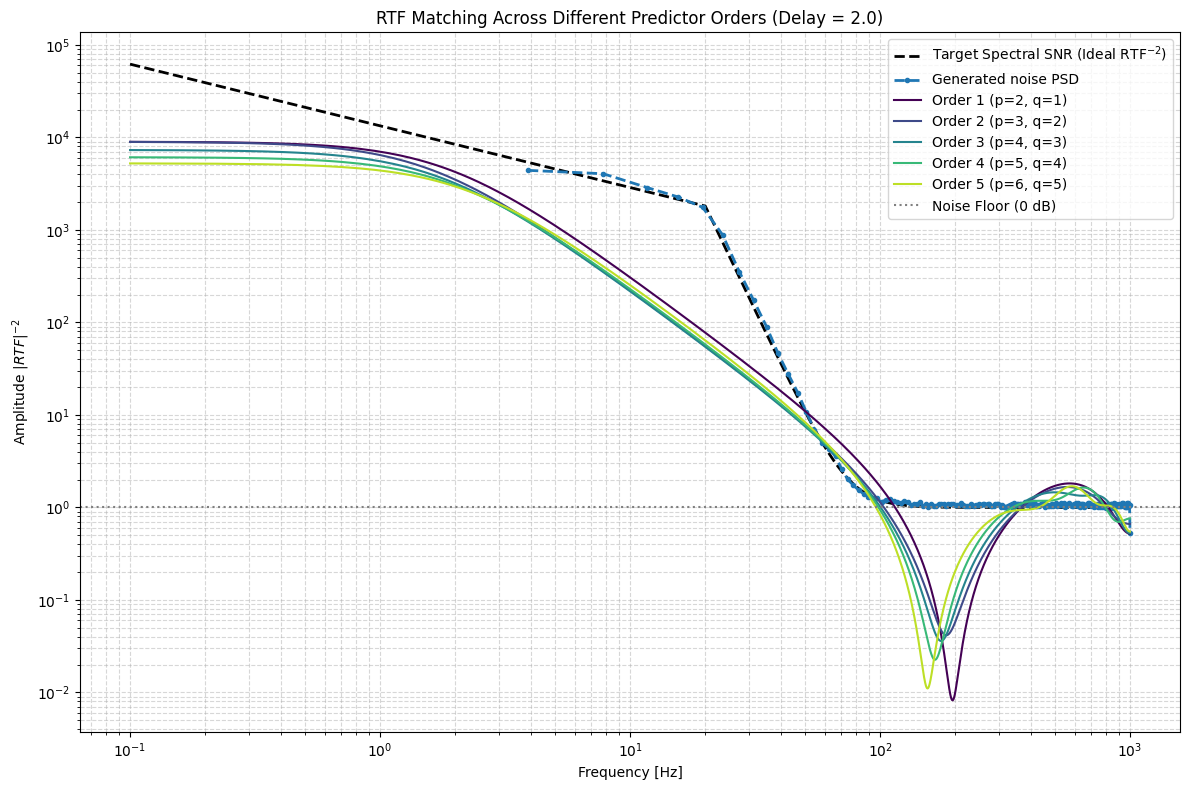

In [3]:

# Parameters
f_sampling = 2000.0          # Loop frequency [Hz]
n_mode = 1                   # Radial order of the mode (e.g., 1 for tilt, >1 for higher)
turb_power = 100.0            # Total turbulence power
noise_power = 1.0            # Total noise power
cutoff_freq = 20.0            # Turbulence Cutoff frequency [Hz]

delay_steps = 2.0            # Non-integer delay steps (e.g., CCD readout + DAC)
p_order = 4                  # Denominator order (p)
q_order = 3                  # Numerator order (q)

# 1. Setup Frequency Axis and Generate PSDs
N_samples = 4096*4
f = np.linspace(0.1, f_sampling / 2, N_samples) #np.logspace(np.log(0.1), np.log(f_sampling / 2), N_samples) #
psd_turb, psd_noise = generate_psd(f, cutoff_freq, n_mode, turb_power, noise_power)

# 2. Simulate the time domain signal advanced by the fractional delay (e'_meas)
e_meas_prime = generate_time_series_with_delay(psd_turb, psd_noise, f, delay_steps)
a_coeffs, b_coeffs = modified_rls_optimizer(e_meas_prime, p_order, q_order)

print("Optimal Numerator Coefficients (a):", a_coeffs)
print("Optimal Denominator Coefficients (b):", b_coeffs)

# 4. Generate the Visualization
evaluate_and_plot(f, psd_turb, psd_noise, a_coeffs, b_coeffs, delay_steps, e_meas_prime, f_sampling)

# Run the comparison
plot_multiple_orders(f, psd_turb, psd_noise, e_meas_prime, delay_steps=delay_steps, f_sampling=f_sampling, max_order=5)